In [8]:
import pandas as pd
import numpy as np
import tensorflow as tf
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
import gc

In [9]:
files = [
    "merged_1star.csv",
    "merged_2star.csv",
    "merged_3star.csv",
    "merged_4star.csv",
    "merged_5star.csv"
]

In [17]:
from sklearn.preprocessing import StandardScaler
import pandas as pd

# ✅ DEFINE FEATURES FIRST
features = ['X_Acc','Y_Acc','Z_Acc','X_Gyro','Y_Gyro','Z_Gyro']
SEQ_LEN = 30

scaler = StandardScaler()

for file in files:
    df = pd.read_csv(file)

    df = df.loc[:, ~df.columns.str.contains('^Unnamed')]

    df = df.dropna(subset=['Rating'])

    # ✅ NOW THIS WILL WORK
    scaler.partial_fit(df[features])

In [18]:
X = []
y = []

for file in files:
    print("Processing:", file)

    df = pd.read_csv(file)

    # clean columns
    df = df.loc[:, ~df.columns.str.contains('^Unnamed')]
    df.columns = df.columns.str.strip()

    # 🔥 fix Sr.No issue
    if 'Sr.No.' in df.columns:
        df = df.rename(columns={'Sr.No.': 'SrNo'})

    df = df.drop(columns=['SrNo'], errors='ignore')

    # 🔥 remove NaN ratings
    df = df.dropna(subset=['Rating'])

    # 🔥 fix timestamp
    df['Timestamp'] = pd.to_numeric(df['Timestamp'], errors='coerce')

    # remove bad timestamps
    df = df.dropna(subset=['Timestamp'])

    # sort
    df = df.sort_values(by='Timestamp')

    # 🔥 detect sessions
    df['time_diff'] = df['Timestamp'].diff()
    df['session_id'] = (df['time_diff'] > 2000).cumsum()

    # drop timestamp columns
    df = df.drop(columns=['Timestamp', 'time_diff'])

    # normalize
    df[features] = scaler.transform(df[features])

    # 🔥 sequence creation per session
    for session in df['session_id'].unique():
        session_df = df[df['session_id'] == session]

        data = session_df[features].values
        labels = session_df['Rating'].values

        if len(data) < SEQ_LEN:
            continue

        for i in range(len(data) - SEQ_LEN):

            # 🔥 skip NaN labels
            if np.isnan(labels[i+SEQ_LEN]):
                continue

            X.append(data[i:i+SEQ_LEN])
            y.append(labels[i+SEQ_LEN])

    del df
    gc.collect()

Processing: merged_1star.csv
Processing: merged_2star.csv
Processing: merged_3star.csv
Processing: merged_4star.csv
Processing: merged_5star.csv


In [19]:
X = np.array(X, dtype=np.float32)
y = np.array(y)

# 🔥 remove any remaining NaNs
mask = ~np.isnan(y)

X = X[mask]
y = y[mask]

y = y.astype(np.int32)

y = y - 1   # 🔥 convert labels 1–5 → 0–4

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (2348078, 30, 6)
y shape: (2348078,)


In [20]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y   # 🔥 VERY IMPORTANT
)

In [21]:
import tensorflow as tf
from tensorflow.keras.layers import Input, Dense, LayerNormalization, Dropout, MultiHeadAttention, GlobalAveragePooling1D
from tensorflow.keras.models import Model

In [22]:
def transformer_block(inputs, head_size, num_heads, ff_dim, dropout=0.1):

    # Self-attention
    x = MultiHeadAttention(
        key_dim=head_size,
        num_heads=num_heads,
        dropout=dropout
    )(inputs, inputs)

    x = Dropout(dropout)(x)
    x = LayerNormalization(epsilon=1e-6)(x + inputs)

    # Feed-forward
    ffn = Dense(ff_dim, activation="relu")(x)
    ffn = Dense(inputs.shape[-1])(ffn)

    x = Dropout(dropout)(ffn)
    return LayerNormalization(epsilon=1e-6)(x + inputs)

In [23]:
def build_transformer(input_shape):

    inputs = Input(shape=input_shape)

    x = transformer_block(inputs, head_size=32, num_heads=2, ff_dim=64)
    x = transformer_block(x, head_size=32, num_heads=2, ff_dim=64)

    x = GlobalAveragePooling1D()(x)

    x = Dense(32, activation="relu")(x)
    x = Dropout(0.2)(x)

    outputs = Dense(5, activation="softmax")(x)

    model = Model(inputs, outputs)

    return model

In [24]:
transformer_model = build_transformer((SEQ_LEN, len(features)))

In [25]:
transformer_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [26]:
history_tf = transformer_model.fit(
    X_train, y_train,
    epochs=10,
    batch_size=64,
    validation_data=(X_test, y_test)
)

Epoch 1/10
29351/29351 ━━━━━━━━━━━━━━━━━━━━ 189s 6ms/step - accuracy: 0.6685 - loss: 0.8460 - val_accuracy: 0.7242 - val_loss: 0.7102
Epoch 2/10
29351/29351 ━━━━━━━━━━━━━━━━━━━━ 167s 6ms/step - accuracy: 0.7149 - loss: 0.7301 - val_accuracy: 0.7209 - val_loss: 0.7609
Epoch 3/10
29351/29351 ━━━━━━━━━━━━━━━━━━━━ 158s 5ms/step - accuracy: 0.7263 - loss: 0.6994 - val_accuracy: 0.7511 - val_loss: 0.6439
Epoch 4/10
29351/29351 ━━━━━━━━━━━━━━━━━━━━ 159s 5ms/step - accuracy: 0.7320 - loss: 0.6816 - val_accuracy: 0.7525 - val_loss: 0.6373
Epoch 5/10
29351/29351 ━━━━━━━━━━━━━━━━━━━━ 207s 6ms/step - accuracy: 0.7371 - loss: 0.6692 - val_accuracy: 0.7457 - val_loss: 0.6625
Epoch 6/10
29351/29351 ━━━━━━━━━━━━━━━━━━━━ 160s 5ms/step - accuracy: 0.7406 - loss: 0.6601 - val_accuracy: 0.7509 - val_loss: 0.6480
Epoch 7/10
29351/29351 ━━━━━━━━━━━━━━━━━━━━ 161s 5ms/step - accuracy: 0.7430 - loss: 0.6529 - val_accuracy: 0.7569 - val_loss: 0.6187
Epoch 8/10
29351/29351 ━━━━━━━━━━━━━━━━━━━━ 159s 5ms/step - ac

In [27]:
import numpy as np
from sklearn.metrics import classification_report

y_pred_tf = np.argmax(transformer_model.predict(X_test), axis=1)

print(classification_report(y_test, y_pred_tf))

14676/14676 ━━━━━━━━━━━━━━━━━━━━ 32s 2ms/step
              precision    recall  f1-score   support

           0       0.71      0.81      0.75    114932
           1       0.79      0.67      0.72     97164
           2       0.76      0.81      0.78    141099
           3       0.79      0.65      0.71     30408
           4       0.84      0.79      0.81     86013

    accuracy                           0.76    469616
   macro avg       0.78      0.74      0.76    469616
weighted avg       0.77      0.76      0.76    469616



In [28]:
transformer_model.save("transformer_model.keras")

**COMPARISSON OF LSTM , GRU AND TRANSFORMER**

In [29]:
from tensorflow.keras.models import load_model

lstm_model = load_model("lstm_driving_model.keras")
gru_model = load_model("gru_driving_model.keras")
transformer_model = load_model("transformer_model.keras")

In [30]:
lstm_loss, lstm_acc = lstm_model.evaluate(X_test, y_test)
gru_loss, gru_acc = gru_model.evaluate(X_test, y_test)
tf_loss, tf_acc = transformer_model.evaluate(X_test, y_test)

print("LSTM:", lstm_acc)
print("GRU:", gru_acc)
print("Transformer:", tf_acc)

14676/14676 ━━━━━━━━━━━━━━━━━━━━ 84s 5ms/step - accuracy: 0.9623 - loss: 0.0873
14676/14676 ━━━━━━━━━━━━━━━━━━━━ 65s 4ms/step - accuracy: 0.9428 - loss: 0.1384
14676/14676 ━━━━━━━━━━━━━━━━━━━━ 37s 2ms/step - accuracy: 0.7645 - loss: 0.6118
LSTM: 0.9623415470123291
GRU: 0.9428001046180725
Transformer: 0.7644692659378052


In [31]:
models = ['LSTM', 'GRU', 'Transformer']
accuracy = [lstm_acc, gru_acc, tf_acc]
loss = [lstm_loss, gru_loss, tf_loss]

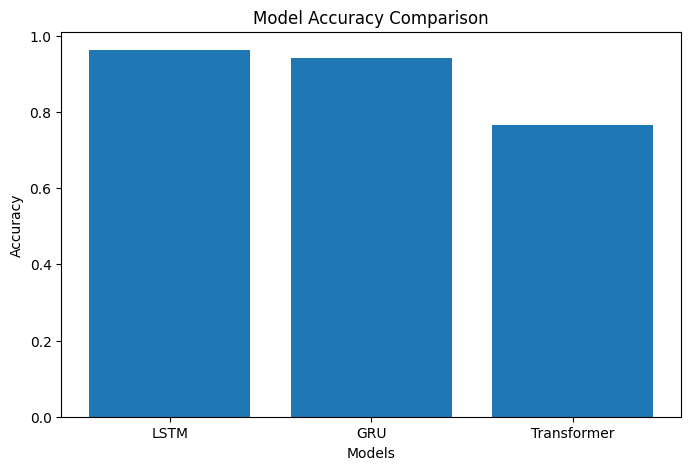

In [32]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.bar(models, accuracy)

plt.title("Model Accuracy Comparison")
plt.ylabel("Accuracy")
plt.xlabel("Models")

plt.show()

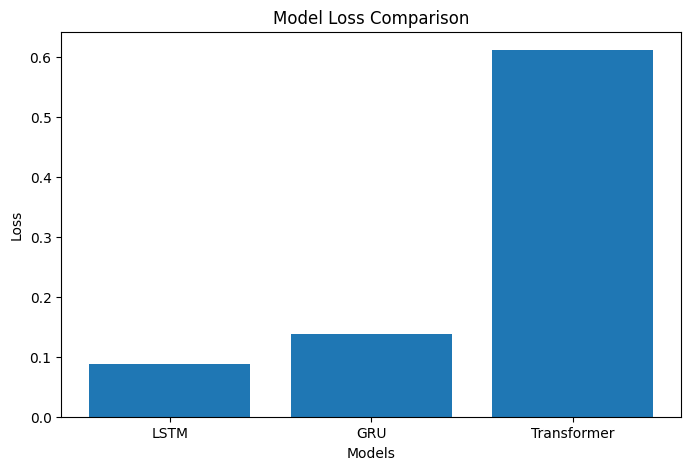

In [33]:
plt.figure(figsize=(8,5))
plt.bar(models, loss)

plt.title("Model Loss Comparison")
plt.ylabel("Loss")
plt.xlabel("Models")

plt.show()

In [34]:
import pandas as pd

df_compare = pd.DataFrame({
    "Model": models,
    "Accuracy": accuracy,
    "Loss": loss
})

print(df_compare)

         Model  Accuracy      Loss
0         LSTM  0.962342  0.087317
1          GRU  0.942800  0.138446
2  Transformer  0.764469  0.611840
